In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt



In [2]:
IMG_SIZE = (128, 128)   
BATCH_SIZE = 32
BASE_PATH = r"D:\Amrita\Semester-2\Deep Learning\Lab Evaluations\week-4\dataset"


In [ ]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    BASE_PATH + r"\train",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'   
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    BASE_PATH + r"\valid",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

class_names = train_ds.class_names
NUM_CLASSES = len(class_names)
print("Classes:", NUM_CLASSES)


Found 6552 files belonging to 102 classes.
Found 818 files belonging to 102 classes.
Classes: 102


In [4]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

normalization_layer = tf.keras.layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))


In [5]:
model = tf.keras.Sequential([
    data_augmentation,

    tf.keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Conv2D(128, (3,3), activation='relu'),
    tf.keras.layers.MaxPooling2D(2,2),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(256, activation='relu'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


c:\Users\aksha\anaconda3\envs\deep_learning\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [6]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)


Epoch 1/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 22s 95ms/step - accuracy: 0.0586 - loss: 4.2307 - val_accuracy: 0.1284 - val_loss: 3.5972
Epoch 2/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 18s 89ms/step - accuracy: 0.1239 - loss: 3.6465 - val_accuracy: 0.2005 - val_loss: 3.2525
Epoch 3/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 20s 98ms/step - accuracy: 0.1723 - loss: 3.3395 - val_accuracy: 0.2616 - val_loss: 2.9254
Epoch 4/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 20s 99ms/step - accuracy: 0.2187 - loss: 3.0888 - val_accuracy: 0.3056 - val_loss: 2.7617
Epoch 5/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 20s 98ms/step - accuracy: 0.2607 - loss: 2.8950 - val_accuracy: 0.3386 - val_loss: 2.5831
Epoch 6/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 20s 98ms/step - accuracy: 0.2952 - loss: 2.7046 - val_accuracy: 0.3692 - val_loss: 2.4215
Epoch 7/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 20s 97ms/step - accuracy: 0.3184 - loss: 2.5834 - val_accuracy: 0.3888 - val_loss: 2.2772
Epoch 8/15
205/205 ━━━━━━━━━━━━━━━━━━━━ 20s 98ms/step - accuracy: 0.3536 - loss: 2.4508 - 

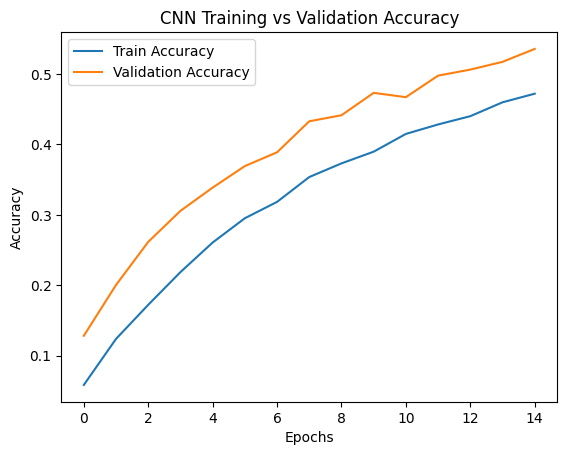

In [7]:
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("CNN Training vs Validation Accuracy")
plt.show()


In [8]:
val_loss, val_acc = model.evaluate(val_ds)
print("CNN Validation Accuracy:", val_acc)


26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.5355 - loss: 1.7929
CNN Validation Accuracy: 0.5354523062705994
